<a href="https://colab.research.google.com/github/Kiranmai-Guddanti/BEE-102-Spring-2025-Assignment/blob/main/01_Norm_Frequency_and_Rescaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**


---



**Fragment length frequency**

You are given a file (see link below) with each line indicating where a DNA fragment has mapped on the chromosome. Your goal is to count individual fragment lengths, and then normalize it by the total count of all fragment lengths. Once you have the normalized count, you will plot that using plotting packages in Python. X-axis will be fragment length (unit: base pairs) and Y-axis will be labelled "Normalized Frequency [A.U.]". Fragment length can simply be calculated by subtracting 2nd column from the 3rd.

query.bed.gz

**Rescaling**

Often, you will received two sets of data with differnt emperical distribution. The goal is to rescale one (query) to the other (reference). In this part, you will write codes to achieve this. You are given a reference distribution (reference.hist) and a query bed file (query.bed.gz). You have to rescale (subsample the data) so that when you draw the normalized frequency, it should almost match the reference.

reference.hist


## **Approach**

---



### **1. Fragment Length Extraction**
- We begin by reading the **query.bed.gz** file, which contains genomic fragment mapping data. Each line provides:
  - **Start position**: The starting coordinate of the fragment.
  - **End position**: The ending coordinate of the fragment.
- The fragment length is calculated as:

       Fragment Length = End Position - Start Position
- These fragment lengths are stored in a list for further processing.

### **2. Frequency Counting and Normalization**
- Using the list of fragment lengths, we count the occurrences of each unique length. This is achieved by creating a **frequency distribution**.
- We then **normalize** the frequency distribution by dividing the count of each fragment length by the total number of fragments. This gives us a **normalized probability distribution** where the sum of all frequencies equals 1.

### **3. Reference Distribution Import**
- The reference distribution is provided in the **reference.hist** file. Each line in this file contains:
  
       Fragment Length , "\t" , Normalized Frequency
  - The **fragment length** is a specific length of DNA fragments.
  - The **normalized frequency** is the proportion of fragments that have this specific length in the reference dataset.
- We read this file and store the data in a dictionary or pandas Series for easy access and manipulation.

### **4. Rescaling (Subsampling)**
- To match the query distribution to the reference distribution, we need to rescale the query.
- For each fragment length in the reference:
  - We determine the **desired count** for that length based on the reference frequency and the total number of fragments in the query.
  - We randomly sample the required number of fragments from the query that match the reference length.
- This process is repeated for all fragment lengths present in both the query and reference.

### **5. Visualization**
- After performing the rescaling, we generate three plots:
  1. The **query distribution**: This is the normalized distribution of fragment lengths from the original query.
  2. The **reference distribution**: This is the given reference data, representing the target distribution.
  3. The **rescaled distribution**: This is the query distribution after rescaling to match the reference.
- All three distributions are plotted on the same graph for **visual comparison**, allowing us to confirm that the rescaling was successful.


In [ ]:
# Essential libraries for data manipulation, visualization, and file handling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gzip
from collections import defaultdict
import random

In [ ]:
# Extracts fragment lengths from a BED file (gzipped)
def extract_fragments_from_bed(path_to_bed):
    fragments = []
    with gzip.open(path_to_bed, 'rt') as file:
        for line in file:
            if line.strip() and not line.startswith('#'):
                parts = line.strip().split('\t')
                if len(parts) >= 3:
                    start = int(parts[1])
                    end = int(parts[2])
                    fragments.append(end - start)
    return pd.Series(fragments, name='frag_len')

query_series = extract_fragments_from_bed('query.bed.gz')


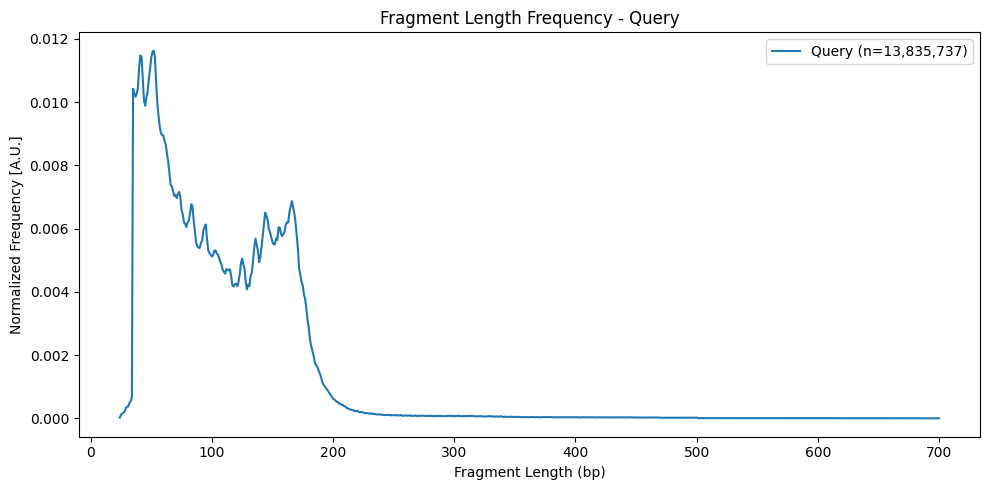

In [ ]:
# Calculate normalized frequencies
frag_counts = query_series.value_counts().sort_index()
norm_freq_query = frag_counts / frag_counts.sum()

# Plot normalized distribution
plt.figure(figsize=(10, 5))
plt.plot(norm_freq_query.index, norm_freq_query.values, label=f'Query (n={len(query_series):,})')
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Frequency - Query")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Load reference histogram into a Pandas Series
def load_reference_distribution(file_path):
    data = pd.read_csv(file_path, sep='\t', header=None, names=['length', 'freq'])
    data['length'] = data['length'].astype(int)
    return data.set_index('length')['freq'].sort_index()

reference_freq = load_reference_distribution('reference.hist')


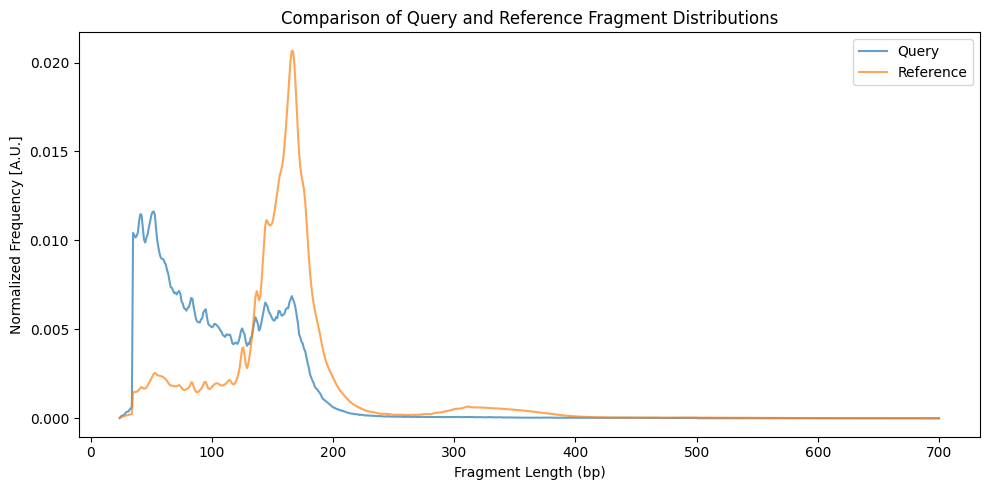

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(norm_freq_query.index, norm_freq_query.values, label='Query', alpha=0.7)
plt.plot(reference_freq.index, reference_freq.values, label='Reference', alpha=0.7)
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Comparison of Query and Reference Fragment Distributions")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Group fragments by length for sampling
fragment_groups = defaultdict(list)
for length in query_series:
    fragment_groups[length].append(length)

# Target number of fragments to match reference scale
target_size = int(len(query_series) * 0.3)
rescaled_pool = []

# Subsampling logic
for length, target_frac in reference_freq.items():
    if length in fragment_groups:
        available_pool = fragment_groups[length]
        desired_n = int(target_frac * target_size)
        rescaled_pool.extend(random.sample(available_pool, min(desired_n, len(available_pool))))

rescaled_series = pd.Series(rescaled_pool)
rescaled_counts = rescaled_series.value_counts().sort_index()
norm_rescaled = rescaled_counts / rescaled_counts.sum()


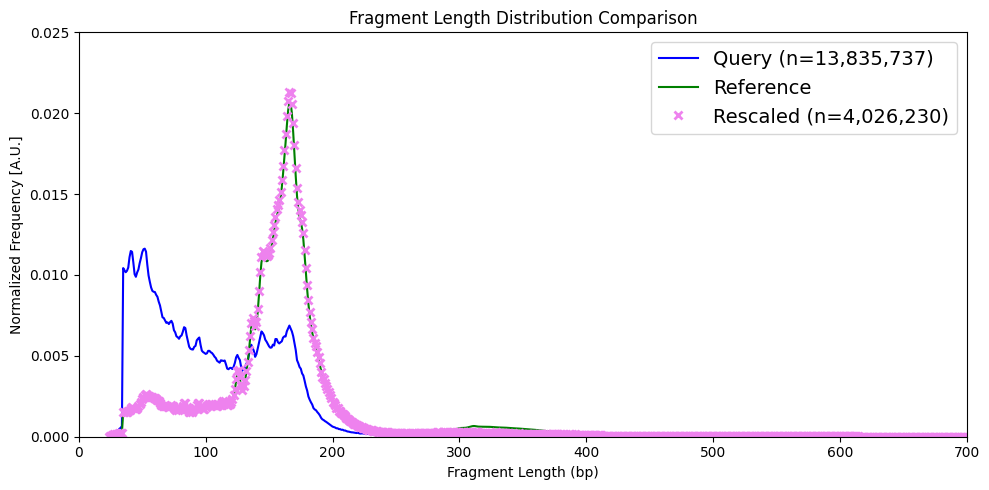

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(norm_freq_query.index, norm_freq_query.values, label=f'Query (n={len(query_series):,})', color='blue')
plt.plot(reference_freq.index, reference_freq.values, label='Reference', color='green')
plt.plot(norm_rescaled.index, norm_rescaled.values, 'x', label=f'Rescaled (n={len(rescaled_pool):,})',
         color='violet', markersize=6, markeredgewidth=2)

plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Distribution Comparison")
plt.xlim(0, 700)
plt.ylim(0, 0.025)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig("rescaled_prediction.png")
plt.show()
